In [45]:
# Core data-handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Suppress non-critical warnings for a clean, professional notebook
import warnings
warnings.filterwarnings('ignore')

# Professional plotting style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
sns.set_style('whitegrid')
sns.set_palette('viridis')

print("All libraries imported successfully.")


All libraries imported successfully.


In [46]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Basic inspection
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))


Dataset shape (rows, columns): (1025, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [47]:
# First 5 rows
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [48]:
# Last 5 rows
df.tail()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [49]:
# A random sample of 5 rows
df.sample(5, random_state=42)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0


## TASK 1 - Dataset Understanding


In [50]:
# Separate numerical vs categorical features programmatically
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target_col)


Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target: target


## TASK 2 - Exploratory Data Analysis (EDA)


In [51]:
# Dataset dimensions and data types
print("Shape:", df.shape)
print()
df.info()


Shape: (1025, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [52]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:\n", missing)
print("\nTotal missing values:", missing.sum())


Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [53]:
# Duplicate rows check
n_duplicates = df.duplicated().sum()
print("Number of exact duplicate rows:", n_duplicates)
print(f"Percentage of dataset that is duplicated: {n_duplicates/len(df)*100:.1f}%")

Number of exact duplicate rows: 723
Percentage of dataset that is duplicated: 70.5%


In [54]:
# Statistical summary of numerical features
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [55]:
# Unique values in categorical/target columns
for col in categorical_features + [target_col]:
    print(f"{col}: {sorted(df[col].unique())}")


sex: [np.int64(0), np.int64(1)]
cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs: [np.int64(0), np.int64(1)]
restecg: [np.int64(0), np.int64(1), np.int64(2)]
exang: [np.int64(0), np.int64(1)]
slope: [np.int64(0), np.int64(1), np.int64(2)]
ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
target: [np.int64(0), np.int64(1)]


In [56]:
# Class distribution of the target variable
class_counts = df['target'].value_counts()
class_pct = df['target'].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_pct.round(2))


target
1    526
0    499
Name: count, dtype: int64

target
1    51.32
0    48.68
Name: proportion, dtype: float64


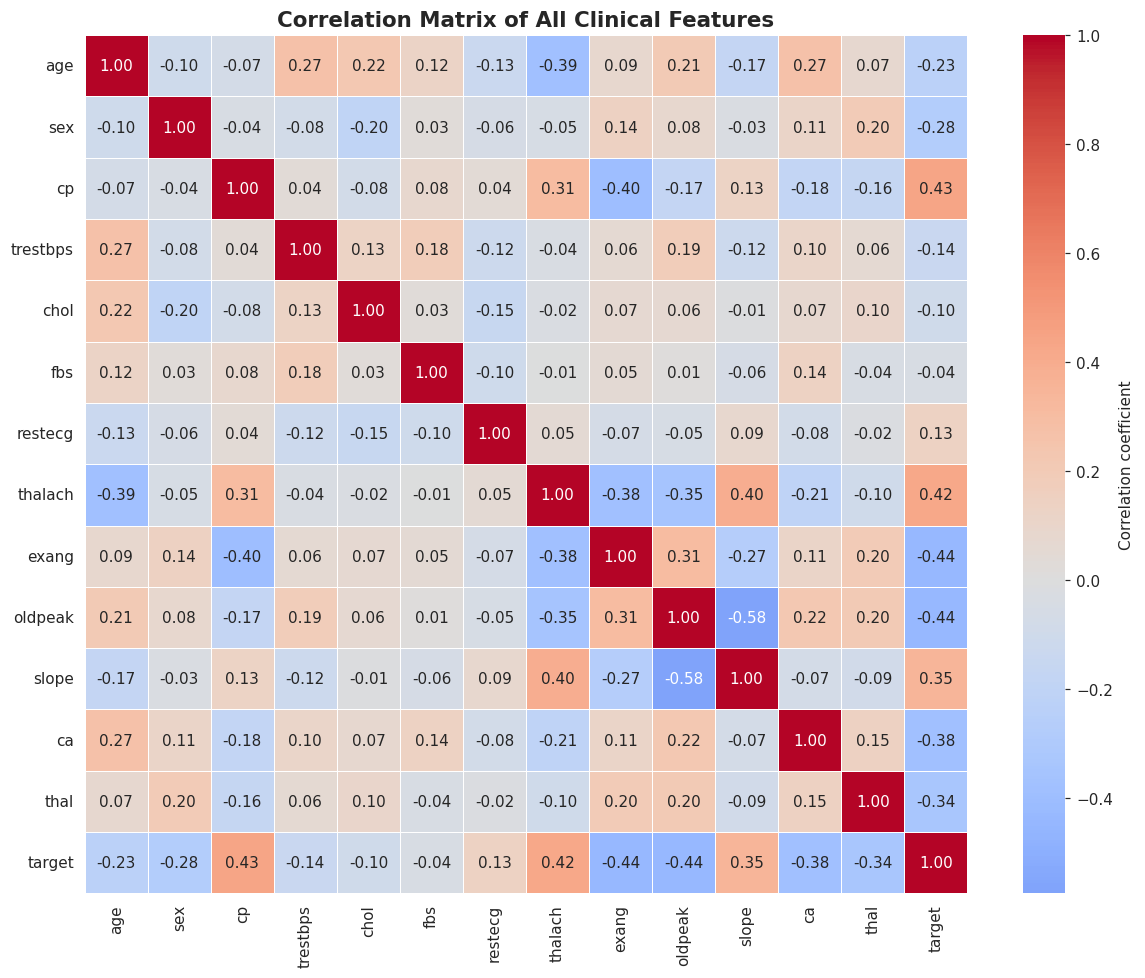

In [57]:
# Correlation matrix heatmap
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Matrix of All Clinical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_01_correlation_heatmap.png')
plt.show()


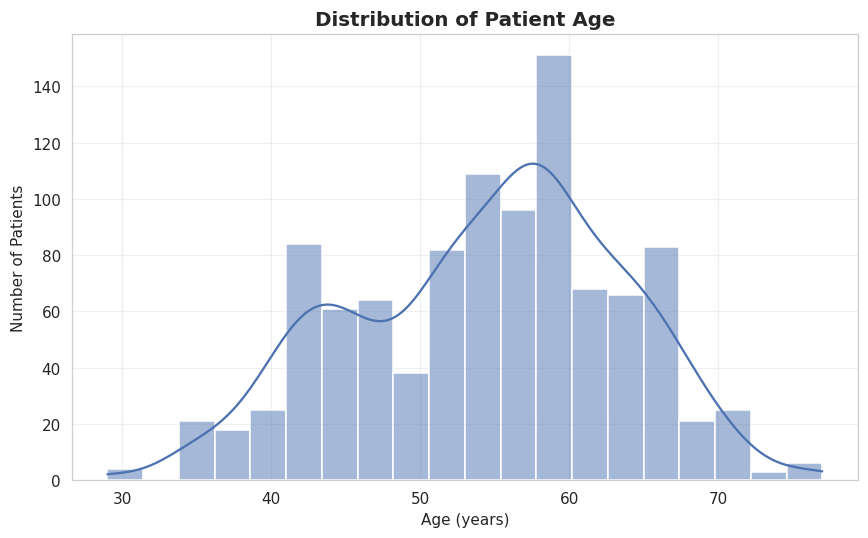

In [58]:
# Visualization 2: Age distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='#4C72B0')
plt.title('Distribution of Patient Age', fontsize=13, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_02_age_histogram.png')
plt.show()


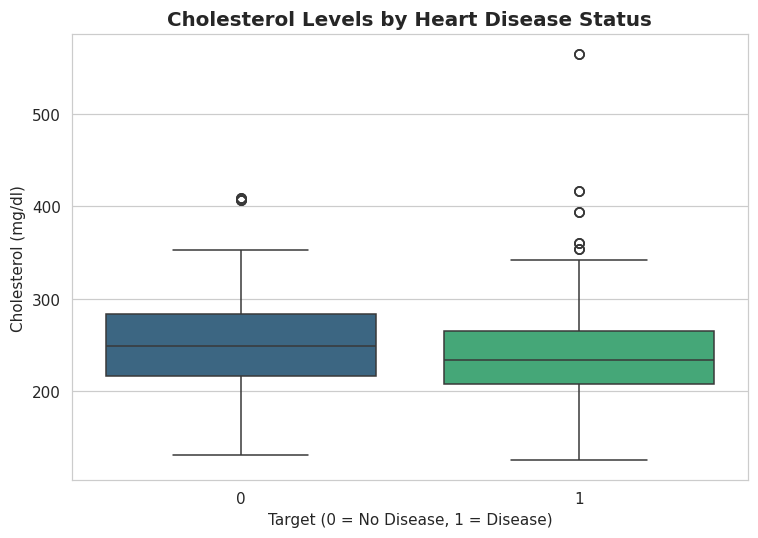

In [59]:
# Visualization 3: Cholesterol by target (Boxplot)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='target', y='chol', hue='target', palette='viridis', legend=False)
plt.title('Cholesterol Levels by Heart Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Cholesterol (mg/dl)')
plt.tight_layout()
plt.savefig('viz_03_cholesterol_boxplot.png')
plt.show()


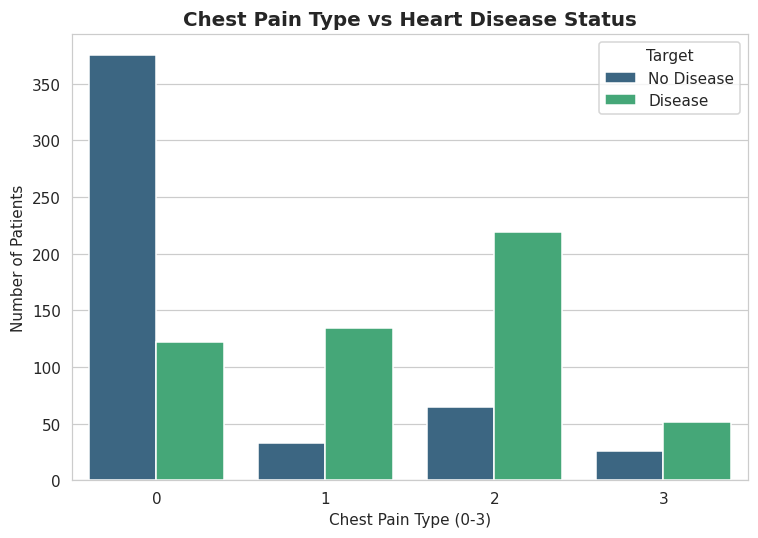

In [60]:
# Visualization 4: Chest pain type vs target (Countplot)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='cp', hue='target', palette='viridis')
plt.title('Chest Pain Type vs Heart Disease Status', fontsize=13, fontweight='bold')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Number of Patients')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('viz_04_chestpain_countplot.png')
plt.show()


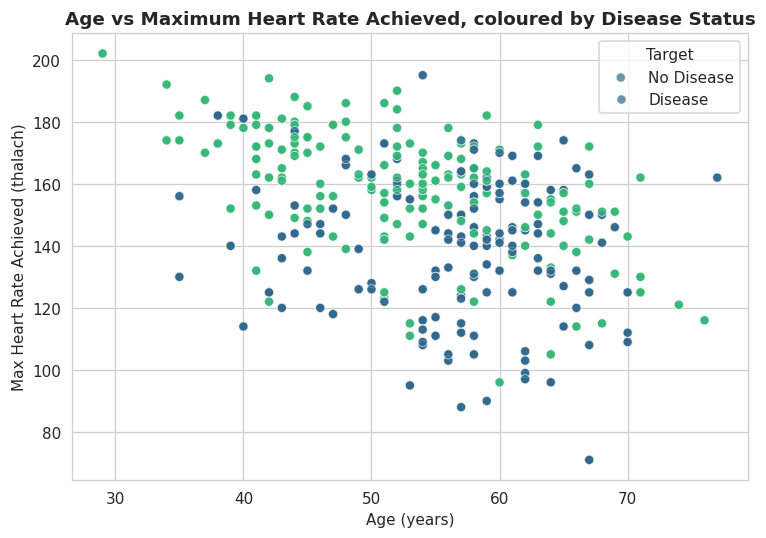

In [61]:
# Visualization 5: Age vs Max Heart Rate (Scatterplot)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='viridis', alpha=0.7)
plt.title('Age vs Maximum Heart Rate Achieved, coloured by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Max Heart Rate Achieved (thalach)')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('viz_05_age_thalach_scatter.png')
plt.show()


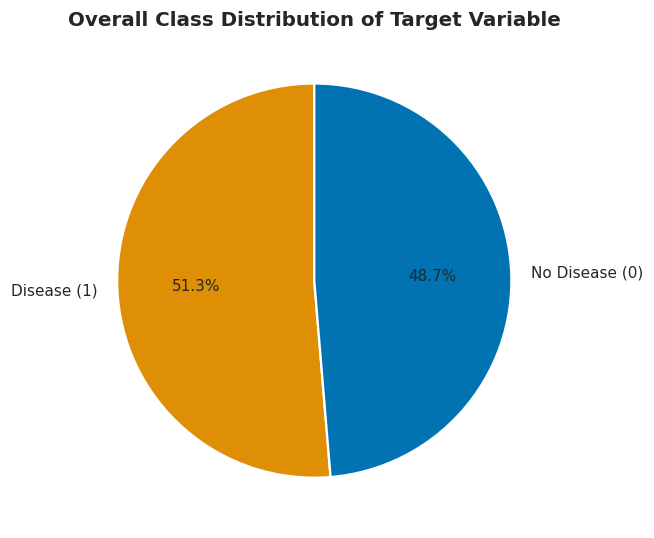

In [62]:
# Visualization 6: Target class distribution (Pie Chart)
plt.figure(figsize=(6, 6))
counts = df['target'].value_counts()
plt.pie(counts, labels=['Disease (1)', 'No Disease (0)'] if counts.index[0]==1 else ['No Disease (0)', 'Disease (1)'],
        autopct='%1.1f%%', colors=['#DE8F05', '#0173B2'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Overall Class Distribution of Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_06_target_pie.png')
plt.show()


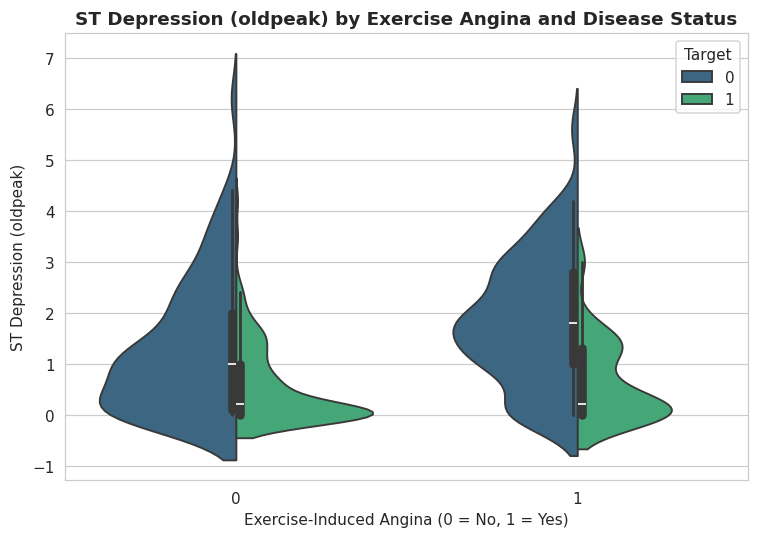

In [63]:
# Visualization 7: Exercise-induced angina vs target (Violin Plot of oldpeak)
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='exang', y='oldpeak', hue='target', split=True, palette='viridis')
plt.title('ST Depression (oldpeak) by Exercise Angina and Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('Exercise-Induced Angina (0 = No, 1 = Yes)')
plt.ylabel('ST Depression (oldpeak)')
plt.legend(title='Target')
plt.tight_layout()
plt.savefig('viz_07_oldpeak_violin.png')
plt.show()


## TASK 3 — Data Cleaning


In [64]:
# --- Step 1: Handle missing values ---
# Why: even though we found 0 missing values, we build a general-purpose strategy
# for production readiness (e.g. new patient records with an unrecorded test).
# Alternative methods: (a) drop rows with missing values, (b) mean/median imputation,
# (c) KNN/model-based imputation. We choose median imputation for numeric columns
# because it is robust to outliers (unlike mean), and mode imputation for categorical
# columns because they are discrete codes.
# Pros: simple, fast, doesn't discard data. Cons: can slightly underestimate variance
# and ignores relationships between features (unlike KNN imputation).

df_clean = df.copy()
for col in numerical_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in categorical_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after imputation step:", df_clean.isnull().sum().sum())


Missing values after imputation step: 0


In [65]:
# --- Step 2: Remove duplicate rows ---
# Why: duplicate patient rows would let identical records appear in BOTH the train
# and test split, artificially inflating test accuracy (a form of data leakage).
# Alternative: keep duplicates but ensure the split is done BEFORE deduplication
# with grouping logic - more complex and unnecessary here since duplicates are exact.
# Pros of dropping: prevents leakage, gives an honest performance estimate.
# Cons: reduces dataset size, which can hurt training data volume.

before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = df_clean.shape[0]
print(f"Rows before dedup: {before}")
print(f"Rows after dedup:  {after}")
print(f"Duplicate rows removed: {before - after}")


Rows before dedup: 1025
Rows after dedup:  302
Duplicate rows removed: 723


In [66]:
# --- Step 3: Handle outliers (IQR capping on numerical features) ---
# Why: extreme values (e.g. a resting blood pressure of 0 or 300) can disproportionately
# influence distance-based models (KNN, SVM) and destabilize scaling.
# Alternative methods: (a) remove outlier rows entirely, (b) z-score capping,
# (c) leave outliers untouched (tree-based models are fairly robust to them).
# We choose IQR-based CAPPING (winsorizing) rather than deletion because in a medical
# dataset, an extreme value is often a real (if rare) patient, and deleting real patients
# discards clinically important information.
# Pros: keeps all patients, reduces the influence of extreme values.
# Cons: slightly distorts the true extreme values; a judgement call vs full removal.

def cap_outliers_iqr(frame, columns, factor=1.5):
    frame = frame.copy()
    report = {}
    for col in columns:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - factor * iqr, q3 + factor * iqr
        n_outliers = ((frame[col] < lower) | (frame[col] > upper)).sum()
        frame[col] = frame[col].clip(lower, upper)
        report[col] = n_outliers
    return frame, report

df_clean, outlier_report = cap_outliers_iqr(df_clean, numerical_features)
print("Outliers capped per column:")
for col, n in outlier_report.items():
    print(f"  {col}: {n}")


Outliers capped per column:
  age: 0
  trestbps: 9
  chol: 5
  thalach: 1
  oldpeak: 5


In [67]:
# --- Step 4: Encoding categorical features ---
# Why: all categorical columns in this dataset are ALREADY represented as integer
# codes (0,1,2,3...) by the original data providers, so no further string-to-number
# encoding (e.g. one-hot encoding) is strictly required for tree-based models.
# For distance-based / linear models (KNN, SVM, Logistic Regression), leaving
# multi-category nominal columns (cp, restecg, slope, thal) as raw integers can
# incorrectly imply an ordinal relationship (e.g. that cp=3 is 'three times' cp=1).
# We therefore apply one-hot encoding to the genuinely NOMINAL multi-category columns
# for the linear/distance-based models, while keeping the raw integer version
# available for tree-based models that don't require it.
# Alternative: label encoding (kept as-is) - simpler but risks false ordinality.
# Pros of one-hot: removes false ordinal assumption. Cons: increases dimensionality.

nominal_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)
print("Shape after one-hot encoding nominal columns:", df_encoded.shape)
print("New columns added:", [c for c in df_encoded.columns if c not in df_clean.columns])


Shape after one-hot encoding nominal columns: (302, 20)
New columns added: ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


In [68]:
# --- Step 5: Feature scaling ---
# Why: features like `age` (range ~29-77) and `chol` (range ~126-564) live on very
# different numeric scales than binary columns (0/1). Distance-based models (KNN, SVM)
# and gradient-based models (Logistic Regression) are sensitive to this scale mismatch,
# with large-range features dominating the distance/gradient calculations.
# Alternative methods: Min-Max scaling (bounds to [0,1], sensitive to outliers),
# Robust scaling (uses median/IQR, very outlier-resistant).
# We use StandardScaler (zero mean, unit variance) as it is the most common default
# and works well after our outlier-capping step above.
# Pros: puts all features on a comparable scale. Cons: less interpretable raw values;
# tree-based models (Decision Tree, Random Forest, XGBoost) do NOT need scaling at all,
# since they split on thresholds rather than distances - we scale a COPY only for the
# models that need it.

scaler = StandardScaler()
X_unscaled = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_scaled = X_unscaled.copy()
scale_cols = numerical_features  # only scale the continuous numeric columns
X_scaled[scale_cols] = scaler.fit_transform(X_unscaled[scale_cols])

print("Scaling applied to:", scale_cols)
X_scaled[scale_cols].describe().T[['mean', 'std']]


Scaling applied to: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


,mean,std
age,-2.676299e-16,1.00166
trestbps,4.529122e-16,1.00166
chol,-1.176395e-16,1.00166
thalach,-4.235023e-16,1.00166
oldpeak,1.176395e-17,1.00166


## TASK 4 — Feature Engineering




In [69]:
df_fe = df_clean.copy()

# 1) Age Groups - clinical risk brackets commonly used in cardiology
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 40, 50, 60, 100],
                             labels=['<40', '40-50', '50-60', '60+'])

# 2) Blood-pressure binning (clinical hypertension categories)
df_fe['bp_category'] = pd.cut(df_fe['trestbps'], bins=[0, 120, 130, 140, 300],
                               labels=['normal', 'elevated', 'stage1_htn', 'stage2_htn'])

# 3) Cholesterol risk band
df_fe['chol_category'] = pd.cut(df_fe['chol'], bins=[0, 200, 240, 700],
                                 labels=['desirable', 'borderline', 'high'])

# 4) Composite clinical Risk Score - simple sum of known binary/ordinal risk factors
# (domain-informed interaction feature, not a single raw column)
df_fe['risk_score'] = (
    (df_fe['age'] > 55).astype(int) +
    df_fe['sex'] +                       # male sex is an established risk factor
    df_fe['exang'] +
    (df_fe['oldpeak'] > 1.0).astype(int) +
    (df_fe['ca'] > 0).astype(int) +
    (df_fe['thal'] == 3).astype(int)
)

# 5) Interaction feature: age x max-heart-rate-deficit
# (captures whether an OLDER patient has a LOW heart rate response - a known red flag)
df_fe['age_thalach_interaction'] = df_fe['age'] * (220 - df_fe['age'] - df_fe['thalach'])

# 6) Log transform of right-skewed oldpeak (many patients have oldpeak = 0)
df_fe['oldpeak_log'] = np.log1p(df_fe['oldpeak'])

print("New engineered columns added:")
print(['age_group', 'bp_category', 'chol_category', 'risk_score',
       'age_thalach_interaction', 'oldpeak_log'])
df_fe[['age_group', 'bp_category', 'chol_category', 'risk_score',
       'age_thalach_interaction', 'oldpeak_log']].head()


New engineered columns added:
['age_group', 'bp_category', 'chol_category', 'risk_score', 'age_thalach_interaction', 'oldpeak_log']


,age_group,bp_category,chol_category,risk_score,age_thalach_interaction,oldpeak_log
0,50-60,elevated,borderline,3,0.0,0.693147
1,50-60,stage1_htn,borderline,4,636.0,1.410987
2,60+,stage2_htn,desirable,5,1750.0,1.280934
3,60+,stage2_htn,borderline,4,-122.0,0.000000
4,60+,stage1_htn,high,3,3224.0,1.064711


In [70]:
# Verify the effect of the log transform on skewness
from scipy.stats import skew
print(f"Skewness of oldpeak (before):     {skew(df_fe['oldpeak']):.3f}")
print(f"Skewness of oldpeak_log (after):  {skew(df_fe['oldpeak_log']):.3f}")


Skewness of oldpeak (before):     0.989
Skewness of oldpeak_log (after):  0.339


In [71]:
# Feature Selection: correlation of engineered risk_score with target,
# compared against the strongest raw feature, to check whether it adds value.
print("Correlation of raw 'cp' with target:         ", round(df_fe['cp'].corr(df_fe['target']), 3))
print("Correlation of engineered 'risk_score' with target:", round(df_fe['risk_score'].corr(df_fe['target']), 3))


Correlation of raw 'cp' with target:          0.432
Correlation of engineered 'risk_score' with target: -0.675


In [72]:
# Before vs After comparison table
comparison = pd.DataFrame({
    'Stage': ['Before Feature Engineering', 'After Feature Engineering'],
    'Number of Columns': [df_clean.shape[1], df_fe.shape[1]],
    'New Engineered Features': [0, 6]
})
comparison


,Stage,Number of Columns,New Engineered Features
0,Before Feature Engineering,14,0
1,After Feature Engineering,20,6


## TASK 5 — Machine Learning Models


In [73]:
# Build the final modelling dataset: original + engineered numeric features, one-hot encoded
df_model = df_fe.copy()

# One-hot encode ALL nominal/categorical columns (raw + newly engineered bins)
nominal_for_model = ['cp', 'restecg', 'slope', 'thal', 'age_group', 'bp_category', 'chol_category']
df_model = pd.get_dummies(df_model, columns=nominal_for_model, drop_first=True)

X = df_model.drop(columns=['target'])
y = df_model['target']

print("Final modelling dataset shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Final modelling dataset shape: (302, 30)
Target distribution:
 target
1    164
0    138
Name: count, dtype: int64


In [74]:
# Train/Test split (stratified to preserve class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric columns for scale-sensitive models (fit ONLY on training data to avoid leakage)
scale_cols_final = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'oldpeak_log',
                     'risk_score', 'age_thalach_interaction']
scale_cols_final = [c for c in scale_cols_final if c in X_train.columns]

final_scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols_final] = final_scaler.fit_transform(X_train[scale_cols_final])
X_test_scaled[scale_cols_final] = final_scaler.transform(X_test[scale_cols_final])

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (241, 30)
Test set size: (61, 30)


In [75]:
# Define all six models. Tree/ensemble/boosting models use the UNSCALED features
# (they don't need scaling); linear/distance/probabilistic models use SCALED features.
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree':        (DecisionTreeClassifier(max_depth=5, random_state=42), False),
    'Random Forest':        (RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42), False),
    'KNN':                  (KNeighborsClassifier(n_neighbors=9), True),
    'Naive Bayes':          (GaussianNB(), True),
    'XGBoost':              (XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                            eval_metric='logloss', random_state=42), False),
}

trained_models = {}
for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    model.fit(Xtr, y_train)
    trained_models[name] = model
    print(f" Trained: {name}")


 Trained: Logistic Regression
 Trained: Decision Tree
 Trained: Random Forest
 Trained: KNN
 Trained: Naive Bayes
 Trained: XGBoost


In [76]:
# Generate predictions for every model on the test set
predictions = {}
probabilities = {}
for name, (model, needs_scaling) in models.items():
    Xte = X_test_scaled if needs_scaling else X_test
    predictions[name] = trained_models[name].predict(Xte)
    probabilities[name] = trained_models[name].predict_proba(Xte)[:, 1]

print("Predictions generated for all models on the held-out test set.")


Predictions generated for all models on the held-out test set.


## TASK 6 — Model Evaluation

| Metric | Meaning | Why it matters here |
|---|---|---|
| **Accuracy** | % of all predictions correct | Easy headline number; reliable here since classes are balanced |
| **Precision** | Of patients predicted "disease", % who truly have it | High precision avoids needlessly alarming/over-testing healthy patients |
| **Recall (Sensitivity)** | Of patients who truly have disease, % correctly caught | **Most critical metric in medicine** — missing a true disease case (false negative) can be life-threatening |
| **F1-score** | Harmonic mean of Precision & Recall | A single balanced summary when both false positives and false negatives carry a cost |
| **ROC-AUC** | Model's ability to rank diseased patients higher than healthy ones, across all thresholds | Threshold-independent view of overall discriminative power |




In [83]:
# Build the full comparison table (Percentage)
results = []

for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        'Model': name,
        'Accuracy (%)': accuracy_score(y_test, y_pred) * 100,
        'Precision (%)': precision_score(y_test, y_pred) * 100,
        'Recall (%)': recall_score(y_test, y_pred) * 100,
        'F1-Score (%)': f1_score(y_test, y_pred) * 100,
        'ROC-AUC (%)': roc_auc_score(y_test, y_prob) * 100,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('ROC-AUC (%)', ascending=False)
    .reset_index(drop=True)
)

# Display with 2 decimal places
results_df.round(2)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Naive Bayes,83.61,87.10,81.82,84.38,89.83
1,Logistic Regression,83.61,84.85,84.85,84.85,88.96
2,Random Forest,81.97,82.35,84.85,83.58,88.10
3,KNN,78.69,79.41,81.82,80.60,87.34
4,XGBoost,81.97,84.38,81.82,83.08,85.06
5,Decision Tree,67.21,72.41,63.64,67.74,66.88


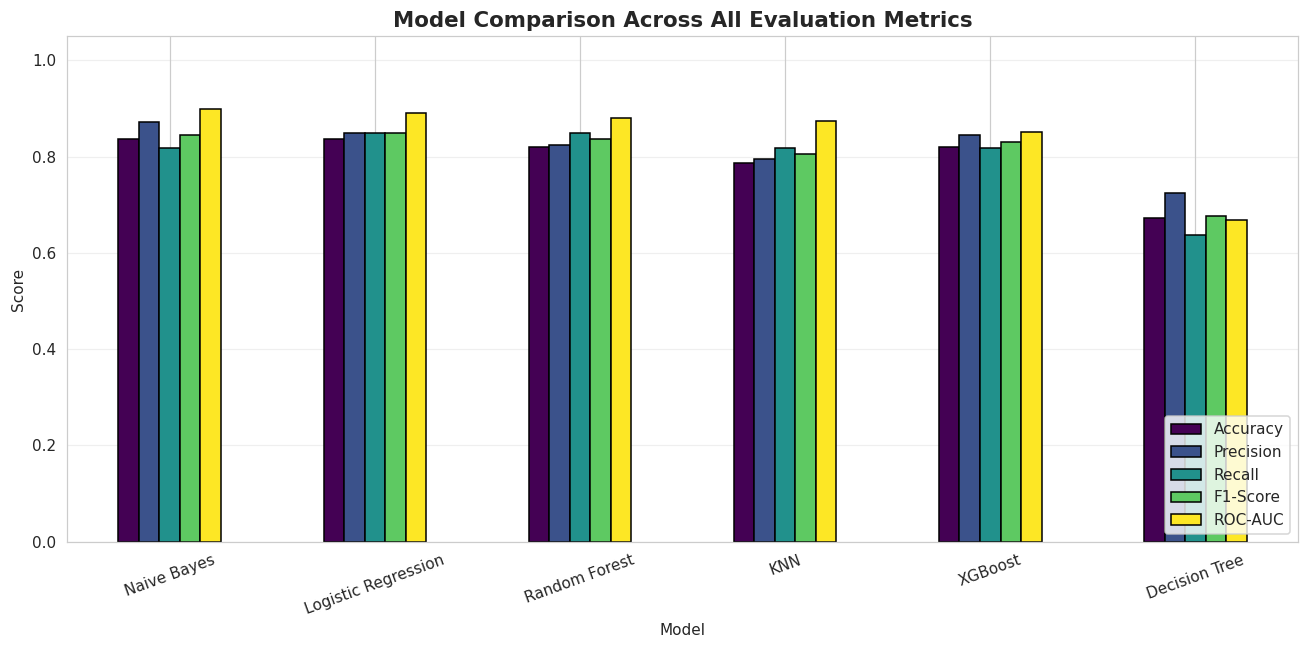

In [78]:
# Bar chart comparing all models across all metrics
plot_df = results_df.set_index('Model')
plot_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('Model Comparison Across All Evaluation Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('viz_08_model_comparison_bar.png')
plt.show()


In [79]:
# Select the best model (highest ROC-AUC)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_needs_scaling = models[best_model_name][1]
print(f"Best Model Selected: {best_model_name}")
print(results_df.iloc[0])


Best Model Selected: Naive Bayes
Model        Naive Bayes
Accuracy        0.836066
Precision       0.870968
Recall          0.818182
F1-Score         0.84375
ROC-AUC         0.898268
Name: 0, dtype: object


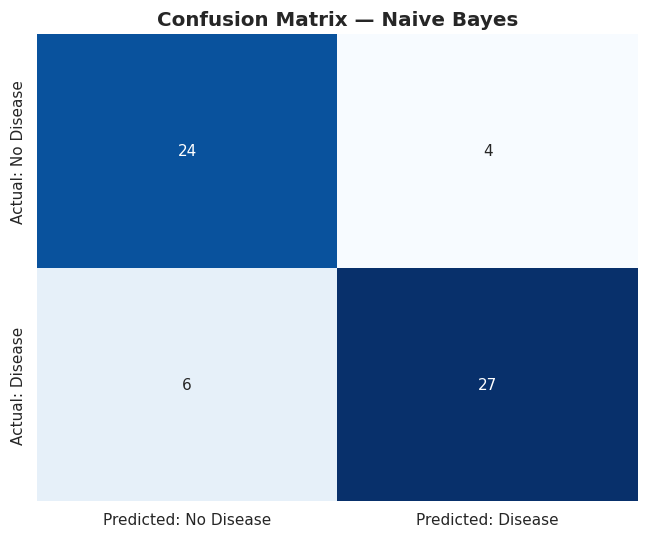

True Negatives:  24  |  False Positives: 4
False Negatives: 6  |  True Positives:  27


In [80]:
# Confusion Matrix for the best model
y_pred_best = predictions[best_model_name]
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_09_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  |  False Positives: {fp}")
print(f"False Negatives: {fn}  |  True Positives:  {tp}")


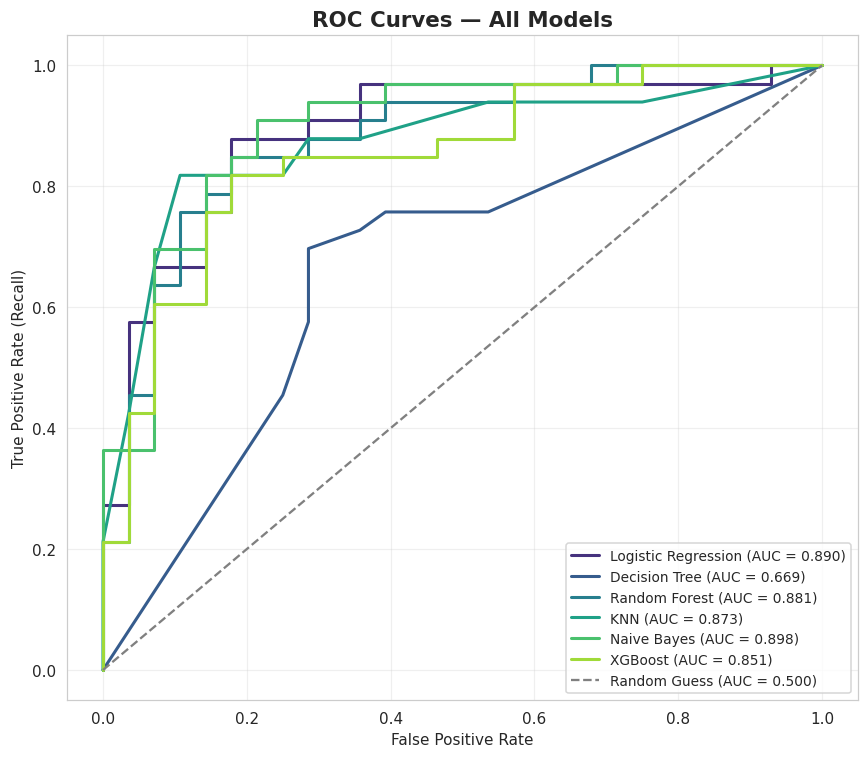

In [81]:
# ROC Curves for all models
plt.figure(figsize=(8, 7))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.500)')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_10_roc_curves.png')
plt.show()


## TASK 7 — Model Interpretation



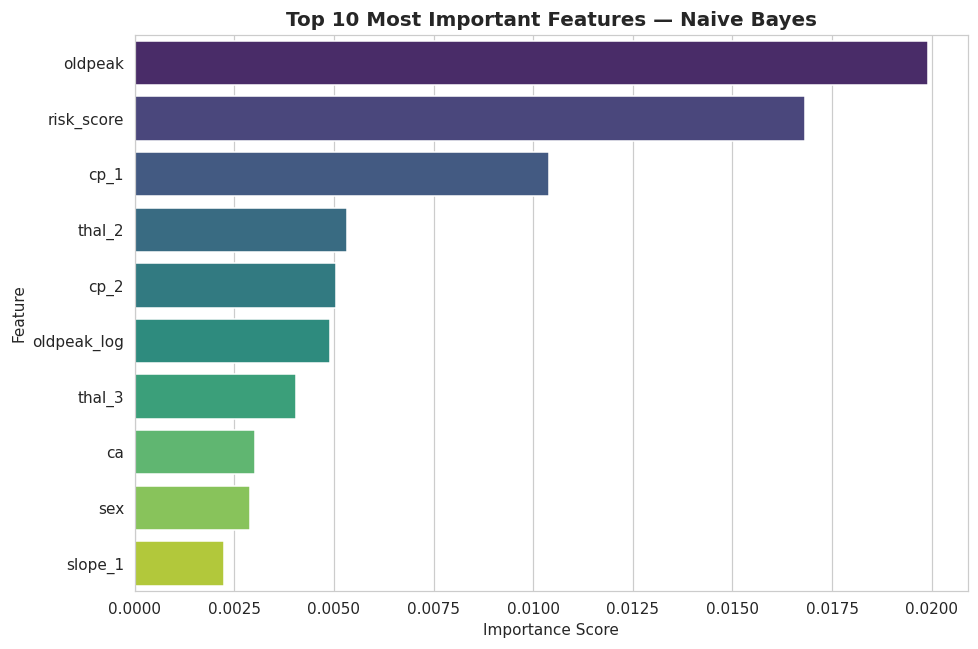

,0
oldpeak,0.019913
risk_score,0.016811
cp_1,0.010390
thal_2,0.005339
cp_2,0.005051
oldpeak_log,0.004906
thal_3,0.004040
ca,0.003030
sex,0.002886
slope_1,0.002237


In [82]:
# Extract feature importance (works directly for tree-based/ensemble/boosting models)
from sklearn.inspection import permutation_importance

X_best = X_test_scaled if best_needs_scaling else X_test

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, 'coef_'):
    # Fallback for linear models: use absolute coefficient magnitude
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
else:
    # General-purpose fallback (e.g. KNN, Naive Bayes): permutation importance,
    # which measures the drop in performance when a feature's values are shuffled.
    perm = permutation_importance(best_model, X_best, y_test, n_repeats=15,
                                   random_state=42, scoring='roc_auc')
    importances = pd.Series(perm.importances_mean, index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='viridis', legend=False)
plt.title(f'Top 10 Most Important Features — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('viz_11_feature_importance.png')
plt.show()

top10
